In [ ]:
%load_ext autoreload
%autoreload 2

import json

pattern = "pattern-12"

entrypoint = pattern
app_cwl_file = f"../cwl-workflow/{pattern}.cwl"

with open(f"../cwl-workflow/{pattern}-inputs.json", "r") as f:
    app_inputs = json.load(f)

try:
    from docs.helpers import plot_cwl, wrap_cwl
except (ImportError, ModuleNotFoundError) as e:

    import os
    import sys

    module_path = os.path.abspath(os.path.join("."))  # or the path to your source code
    sys.path.insert(0, module_path)

from helpers import WorkflowViewer, WorkflowWrapper, additional_inputs
from cwl_loader import dump_cwl
from IPython.display import Markdown, display
import json

In [2]:
wf = WorkflowViewer.from_file(app_cwl_file, entrypoint)

2025-12-03 10:40:38.851 | DEBUG    | cwl_loader:load_cwl_from_location:228 - Loading CWL document from ../cwl-workflow/pattern-12.cwl...
2025-12-03 10:40:38.853 | DEBUG    | cwl_loader:_load_cwl_from_stream:231 - Reading stream from ../cwl-workflow/pattern-12.cwl...
2025-12-03 10:40:38.874 | DEBUG    | cwl_loader:load_cwl_from_stream:203 - CWL data of type <class 'ruamel.yaml.comments.CommentedMap'> successfully loaded from stream
2025-12-03 10:40:38.875 | DEBUG    | cwl_loader:load_cwl_from_yaml:130 - Updating the model from version 'v1.0' to version 'v1.2'...
2025-12-03 10:40:38.875 | DEBUG    | cwl_loader:load_cwl_from_yaml:141 - Raw CWL document successfully updated to v1.2!
2025-12-03 10:40:38.876 | DEBUG    | cwl_loader:load_cwl_from_yaml:145 - Parsing the raw CWL document to the CWL Utils DOM...
2025-12-03 10:40:39.684 | DEBUG    | cwl_loader:load_cwl_from_yaml:158 - Raw CWL document successfully parsed to the CWL Utils DOM!
2025-12-03 10:40:39.685 | DEBUG    | cwl_loader:load_c

## Application Package Pattern 12

This patterns publishes all products generated by all steps

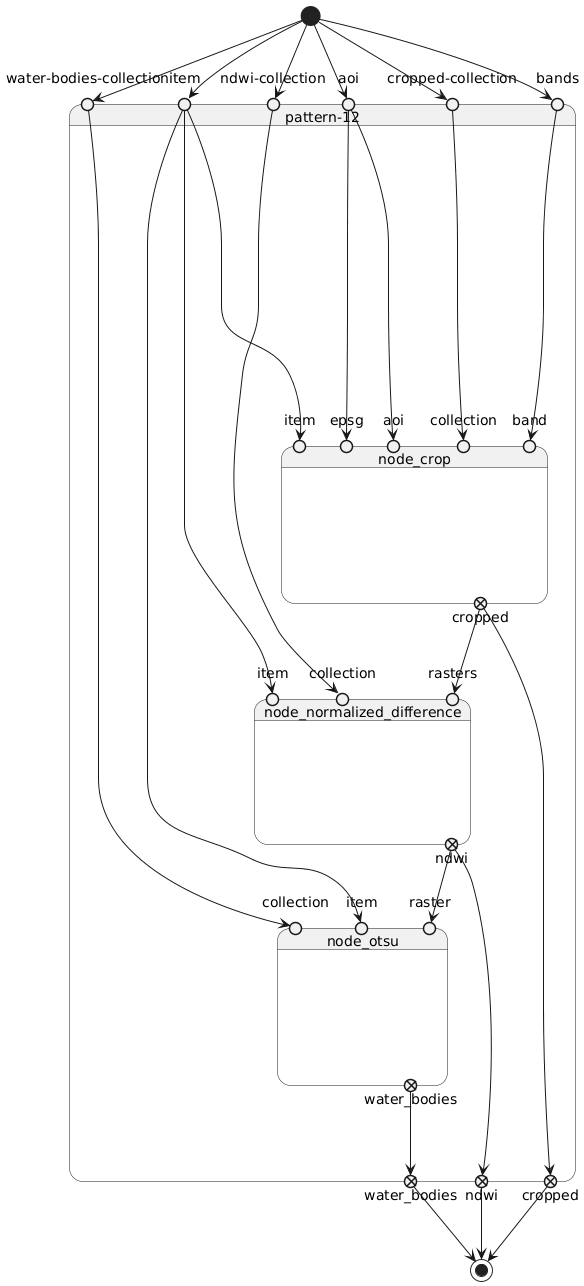

In [ ]:
wf.display_state_diagram()

### Inputs

In [4]:
wf.display_inputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `aoi` | `https://raw.githubusercontent.com/eoap/schemas/main/ogc.yaml#BBox` | area of interest | area of interest as a bounding box |
| `bands` | `string[]` | bands used for the NDWI | bands used for the NDWI |
| `item` | `Directory` | Landsat-8/9 acquisition reference | Landsat-8/9 acquisition reference |
| `cropped-collection` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | cropped reflectances STAC Collection | STAC Collection URL for the cropped reflectances |
| `ndwi-collection` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | NDWI STAC Collection | STAC Collection URL for the NDWI |
| `water-bodies-collection` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | Water bodies STAC Collection | STAC Collection URL for the water bodies |


### Steps

In [5]:
wf.display_steps()

| Id | Runs | Label | Doc |
| --- | --- | --- | --- |
| `node_crop` | `#crop` | None | None |
| `node_normalized_difference` | `#norm_diff` | None | None |
| `node_otsu` | `#otsu` | None | None |


### Outputs

In [6]:
wf.display_outputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `cropped` | `Directory[]` | Cropped reflectances | Cropped reflectances |
| `ndwi` | `Directory` | Normalized Difference Water Index | Normalized Difference Water Index calculated from the input bands |
| `water_bodies` | `Directory` | Water bodies detected | Water bodies detected based on the NDWI and otsu threshold |


## Data flow management

In [7]:
w = WorkflowWrapper(workflow=wf.workflow, entrypoint=entrypoint)
wrapped = w.wrap()

app_cwl_file = f".{entrypoint}.cwl"

with open(app_cwl_file, "w") as f:
    dump_cwl(process=wrapped, stream=f)

2025-12-03 10:40:43.006 | DEBUG    | cwl_loader:load_cwl_from_location:228 - Loading CWL document from https://raw.githubusercontent.com/eoap/application-package-patterns/refs/heads/develop/templates/stage-in.cwl...
2025-12-03 10:40:43.062 | DEBUG    | cwl_loader:_load_cwl_from_stream:231 - Reading stream from https://raw.githubusercontent.com/eoap/application-package-patterns/refs/heads/develop/templates/stage-in.cwl...
2025-12-03 10:40:43.065 | DEBUG    | cwl_loader:load_cwl_from_stream:203 - CWL data of type <class 'ruamel.yaml.comments.CommentedMap'> successfully loaded from stream
2025-12-03 10:40:43.066 | DEBUG    | cwl_loader:load_cwl_from_yaml:130 - Updating the model from version 'v1.0' to version 'v1.2'...
2025-12-03 10:40:43.066 | DEBUG    | cwl_loader:load_cwl_from_yaml:141 - Raw CWL document successfully updated to v1.2!
2025-12-03 10:40:43.067 | DEBUG    | cwl_loader:load_cwl_from_yaml:145 - Parsing the raw CWL document to the CWL Utils DOM...
2025-12-03 10:40:43.567 | DE

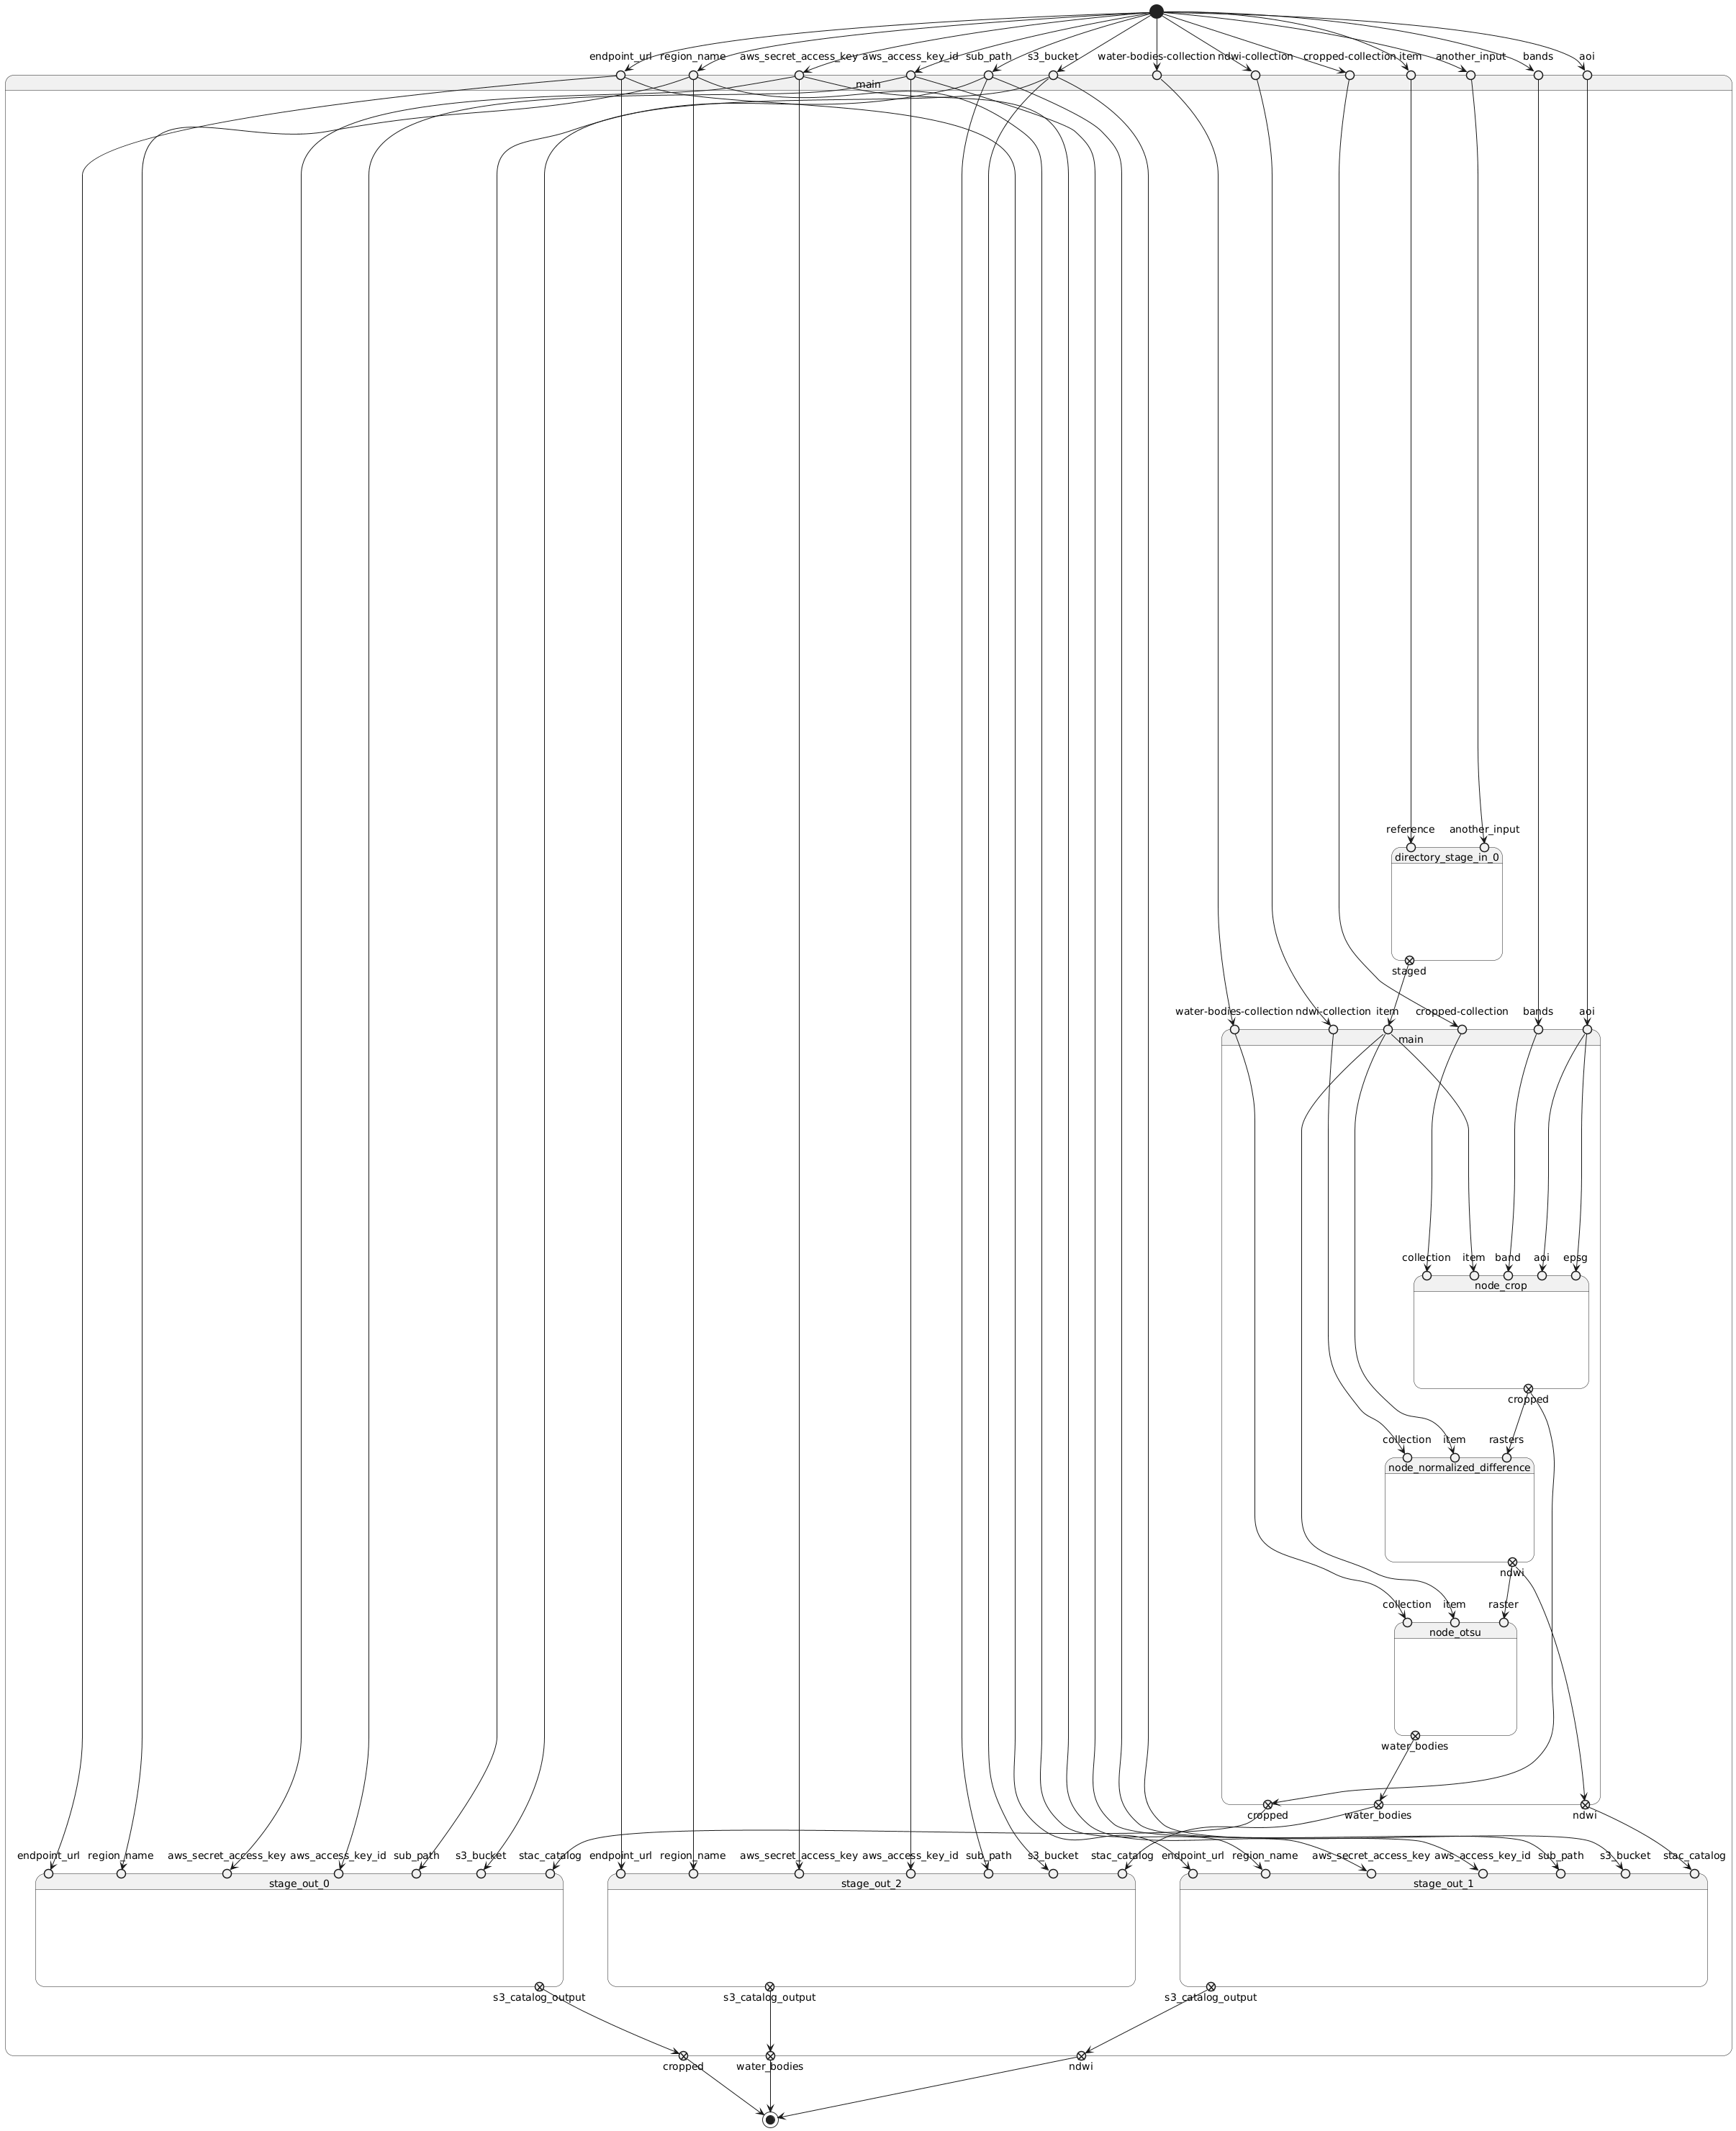

In [ ]:
wf = WorkflowViewer(cwl_file=app_cwl_file, workflow=wrapped, entrypoint="main")

wf.display_state_diagram()

### Workflow sequence diagram

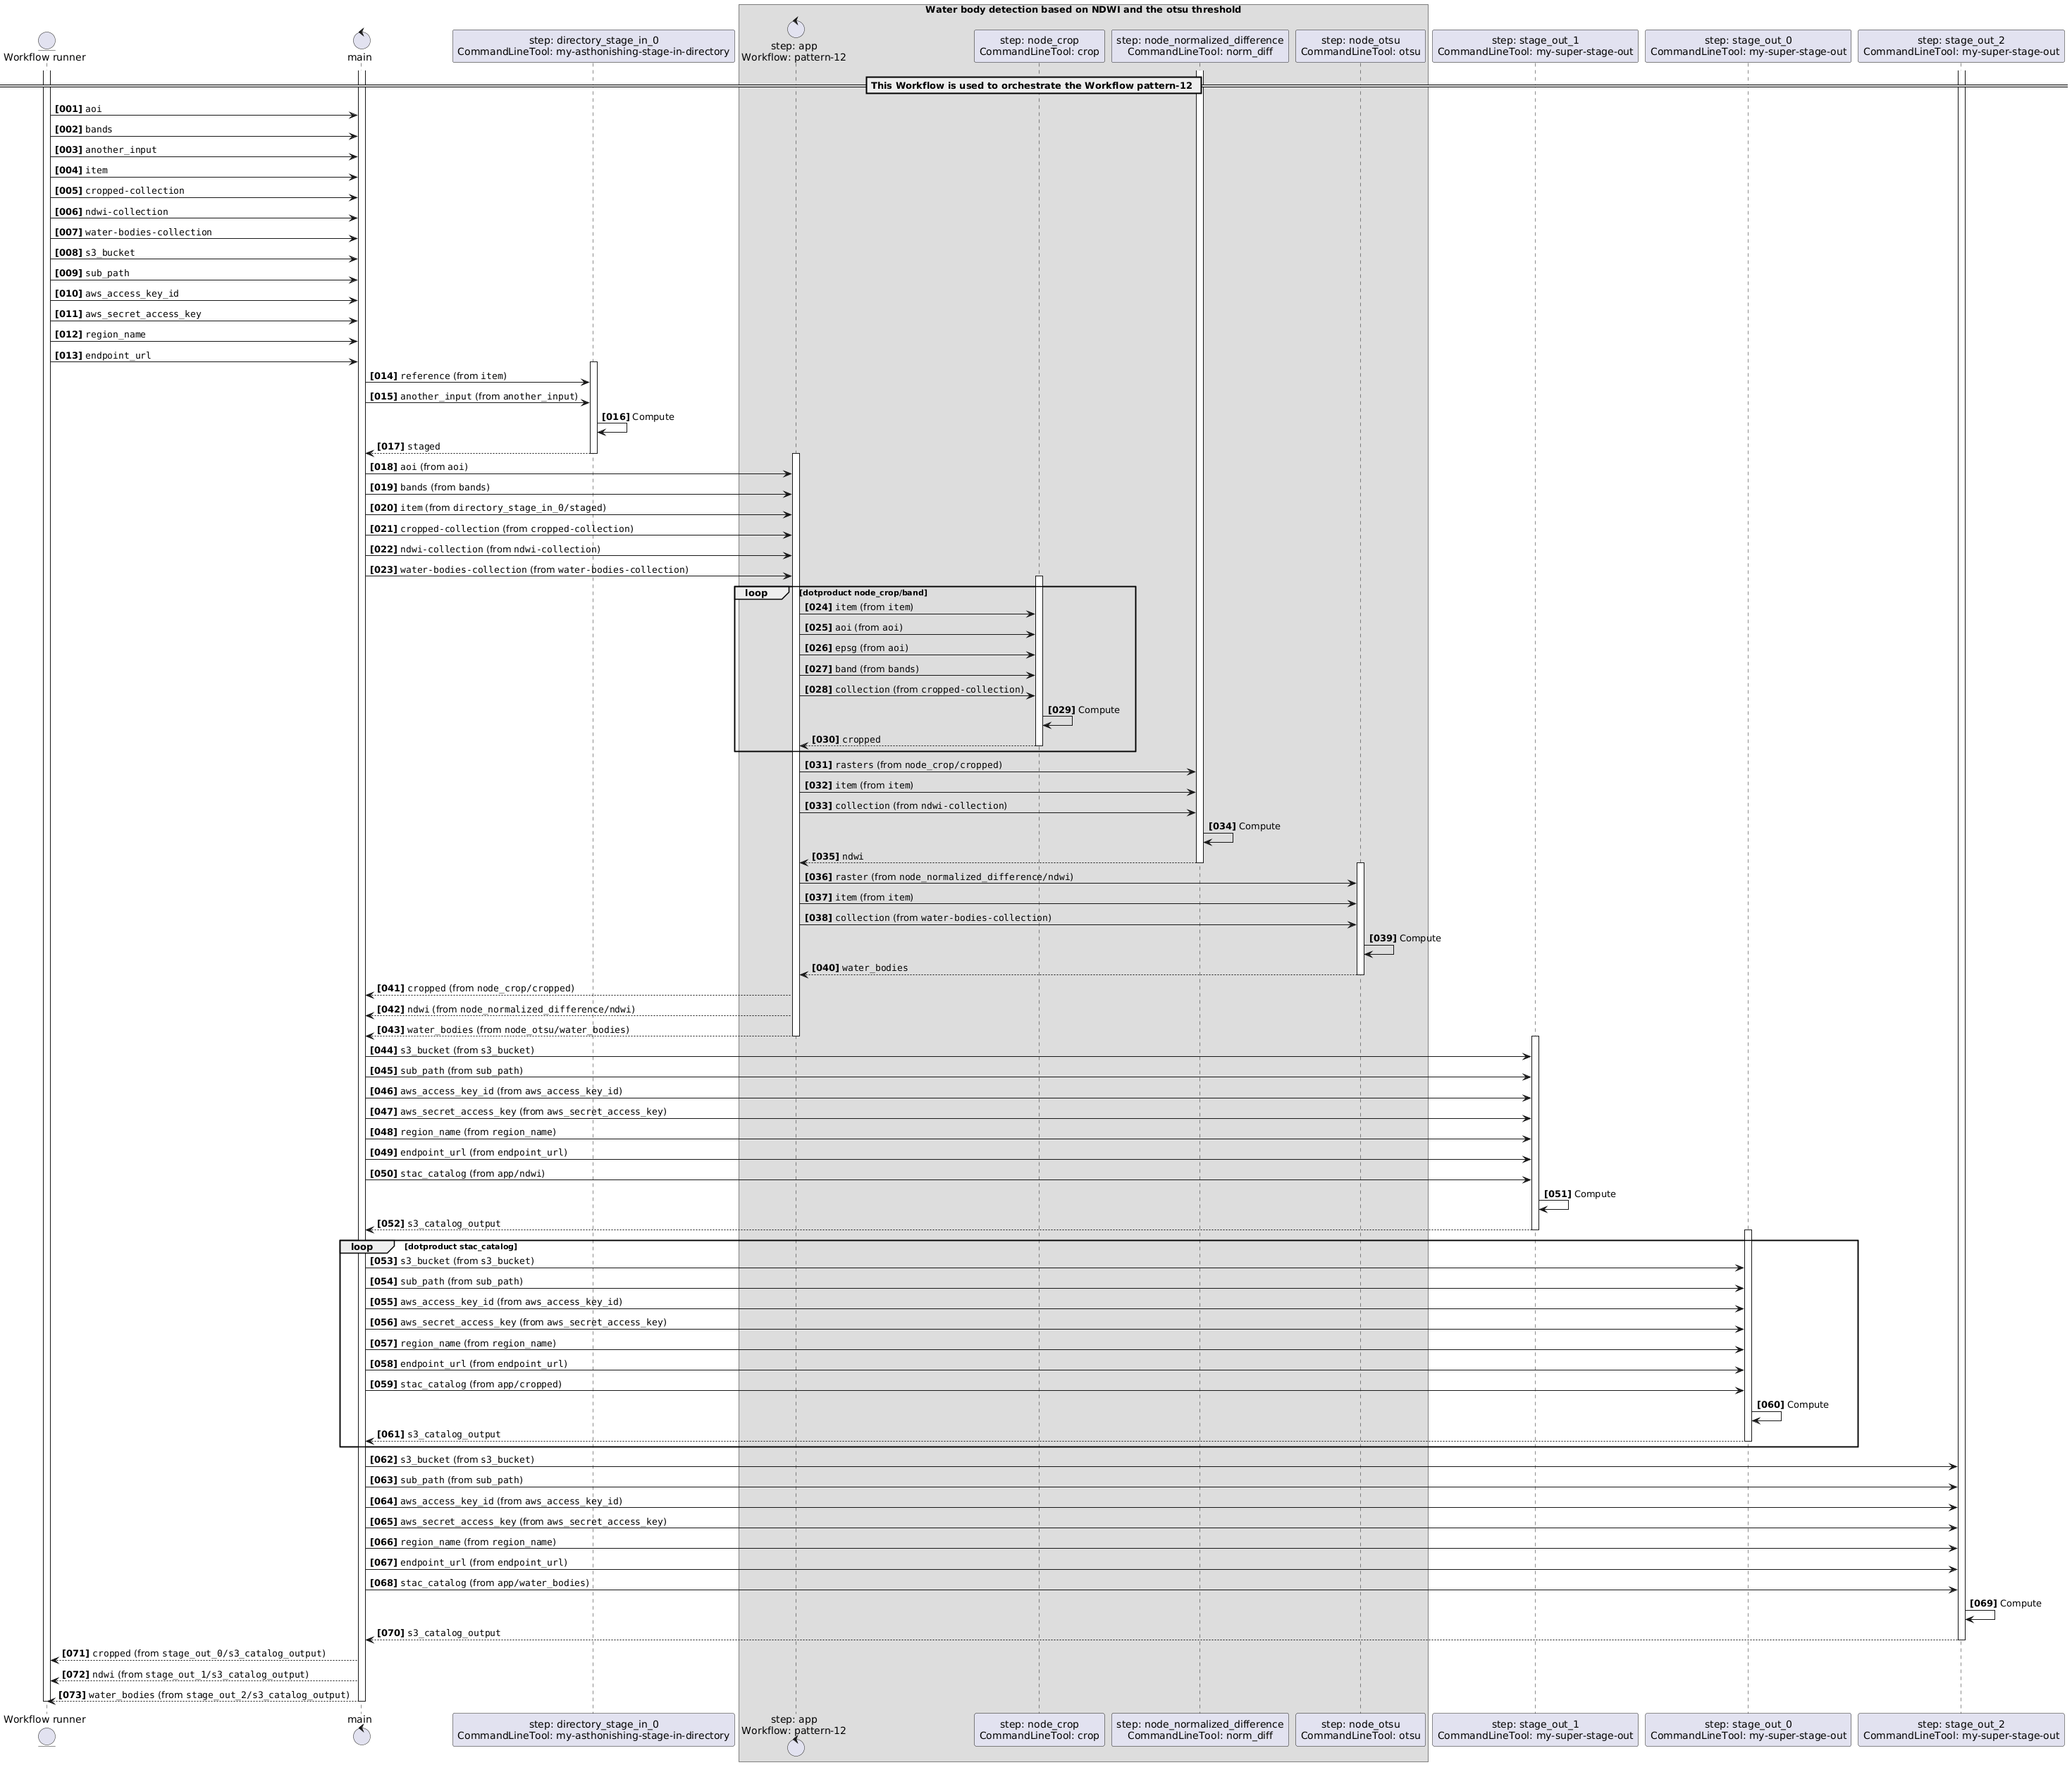

In [9]:
wf.display_sequence_diagram()

### Inputs

In [10]:
wf.display_inputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `aoi` | `https://raw.githubusercontent.com/eoap/schemas/main/ogc.yaml#BBox` | area of interest - pattern-12/aoi | area of interest as a bounding box - This parameter is derived from pattern-12/aoi |
| `bands` | `string[]` | bands used for the NDWI - pattern-12/bands | bands used for the NDWI - This parameter is derived from pattern-12/bands |
| `another_input` | `string` | Another Input - my-asthonishing-stage-in-directory/another_input | An additional input for demonstration purposes - This parameter is derived from my-asthonishing-stage-in-directory/another_input |
| `item` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | Landsat-8/9 acquisition reference - pattern-12/item | Landsat-8/9 acquisition reference - This parameter is derived from pattern-12/item |
| `cropped-collection` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | cropped reflectances STAC Collection - pattern-12/cropped-collection | STAC Collection URL for the cropped reflectances - This parameter is derived from pattern-12/cropped-collection |
| `ndwi-collection` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | NDWI STAC Collection - pattern-12/ndwi-collection | STAC Collection URL for the NDWI - This parameter is derived from pattern-12/ndwi-collection |
| `water-bodies-collection` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | Water bodies STAC Collection - pattern-12/water-bodies-collection | STAC Collection URL for the water bodies - This parameter is derived from pattern-12/water-bodies-collection |
| `s3_bucket` | `string` | my-super-stage-out/s3_bucket | This parameter is derived from: my-super-stage-out/s3_bucket |
| `sub_path` | `string` | my-super-stage-out/sub_path | This parameter is derived from: my-super-stage-out/sub_path |
| `aws_access_key_id` | `string` | my-super-stage-out/aws_access_key_id | This parameter is derived from: my-super-stage-out/aws_access_key_id |
| `aws_secret_access_key` | `string` | my-super-stage-out/aws_secret_access_key | This parameter is derived from: my-super-stage-out/aws_secret_access_key |
| `region_name` | `string` | my-super-stage-out/region_name | This parameter is derived from: my-super-stage-out/region_name |
| `endpoint_url` | `string` | my-super-stage-out/endpoint_url | This parameter is derived from: my-super-stage-out/endpoint_url |


### Steps

In [11]:
wf.display_steps()

| Id | Runs | Label | Doc |
| --- | --- | --- | --- |
| `directory_stage_in_0` | `#my-asthonishing-stage-in-directory` | None | None |
| `app` | `#pattern-12` | None | None |
| `stage_out_1` | `#my-super-stage-out` | None | None |
| `stage_out_0` | `#my-super-stage-out` | None | None |
| `stage_out_2` | `#my-super-stage-out` | None | None |


### Outputs

In [12]:
wf.display_outputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `cropped` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI[]` | Cropped reflectances | Cropped reflectances |
| `ndwi` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | Normalized Difference Water Index | Normalized Difference Water Index calculated from the input bands |
| `water_bodies` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | Water bodies detected | Water bodies detected based on the NDWI and otsu threshold |


## Execution


In [13]:
from cwltool.main import main
from io import StringIO
import argparse
import yaml

In [ ]:
with open(".params.yaml", "w") as f:
    yaml.dump({**app_inputs, **additional_inputs}, f)

md = f"""

### Inputs

```json
{json.dumps({**app_inputs, **additional_inputs}, indent=2)}
```
"""

display(Markdown(md))



### Inputs

```json
{
  "aoi": {
    "class": "https://raw.githubusercontent.com/eoap/schemas/main/ogc.yaml#BBox",
    "bbox": [
      -118.985,
      38.432,
      -118.183,
      38.938
    ],
    "crs": "CRS84"
  },
  "item": {
    "class": "https://raw.githubusercontent.com/eoap/schemas/main/ogc.yaml#URI",
    "value": "https://planetarycomputer.microsoft.com/api/stac/v1/collections/landsat-c2-l2/items/LC08_L2SP_042033_20231007_02_T1"
  },
  "bands": [
    "green",
    "nir08"
  ],
  "cropped-collection": {
    "class": "https://raw.githubusercontent.com/eoap/schemas/main/ogc.yaml#URI",
    "value": "https://github.com/eoap/application-package-patterns/raw/refs/heads/develop/collections/cropped_collection.json"
  },
  "ndwi-collection": {
    "class": "https://raw.githubusercontent.com/eoap/schemas/main/ogc.yaml#URI",
    "value": "https://github.com/eoap/application-package-patterns/raw/refs/heads/develop/collections/ndi_collection.json"
  },
  "water-bodies-collection": {
    "class": "https://raw.githubusercontent.com/eoap/schemas/main/ogc.yaml#URI",
    "value": "https://github.com/eoap/application-package-patterns/raw/refs/heads/develop/collections/water_bodies_collection.json"
  }
}
```


In [15]:
parsed_args = argparse.Namespace(
    podman=False,
    debug=False,
    validate=False,
    outdir="./runs",
    workflow=f"{app_cwl_file}#main",
    job_order=[".params.yaml"],
)

stream_out = StringIO()
stream_err = StringIO()

res = main(
    args=parsed_args,
    stdout=stream_out,
    stderr=stream_err,
)

if res == 0:
    md = f"""

### Outputs

```json
{stream_out.getvalue()}
```
    """
else:
    md = f"""

### Errors

CWL execution terminated with errors:

```
{stream_err.getvalue()}
```
    """

display(Markdown(md))

KeyboardInterrupt: 